In [16]:
import numpy as np
import duckdb as db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
import scipy.stats as stats

In [17]:
csv = 'social_media_productivity_6000.csv'
df = pd.read_csv(csv)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


In [18]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [19]:
print("\nVerificando valores ausentes:\n")
print(df.isnull().sum())


Verificando valores ausentes:

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


In [20]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


In [21]:
# APPROACH 1: excluding lines with null values.

In [22]:
dflimpo = df.dropna().copy()
print("\n Verifying missing values:\n")
print(dflimpo.isnull().sum())


 Verifying missing values:

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


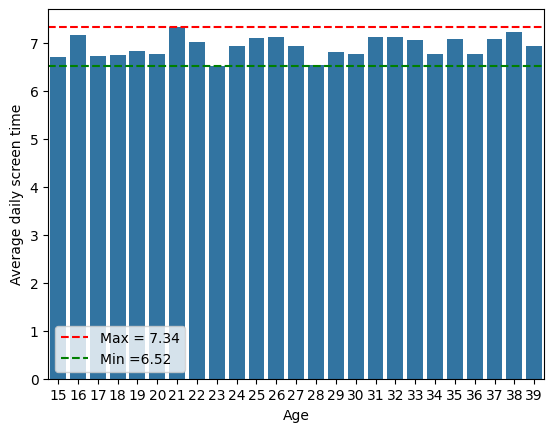

In [23]:
usomedioidade = db.query('SELECT CAST(age AS int) as age, AVG(daily_screen_Time) FROM dflimpo GROUP BY age ORDER BY age ASC').df()

sns.barplot(data=usomedioidade, x='age', y ='avg(daily_screen_Time)')
val_max = usomedioidade['avg(daily_screen_Time)'].max()
val_min = usomedioidade['avg(daily_screen_Time)'].min()
plt.axhline(y=val_max, color='r', linestyle='--', label=f'Max = {val_max:.2f}')
plt.axhline(y=val_min, color='g', linestyle='--', label=f'Min ={val_min:.2f}')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Average daily screen time')
plt.show()

In [24]:
# Segmented analysis by age group

bins = [15, 19, 25, 40] 
labels = ['15-18', '19-24', '25-39']
dflimpo['faixa_etaria'] = pd.cut(dflimpo['age'], bins=bins, labels=labels, right=False)
dflimpo

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score,faixa_etaria
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49,19-24
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54,25-39
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52,25-39
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82,25-39
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09,19-24
...,...,...,...,...,...,...,...,...,...,...
5994,27.0,8.93,5.70,4.17,6.19,148.0,100.00,High,18.44,25-39
5995,20.0,2.05,0.71,7.92,4.13,48.0,100.00,Low,84.55,19-24
5996,28.0,6.28,4.90,4.07,5.64,198.0,99.52,Medium,37.63,25-39
5997,19.0,3.97,3.40,0.93,6.10,183.0,98.65,Medium,6.67,19-24


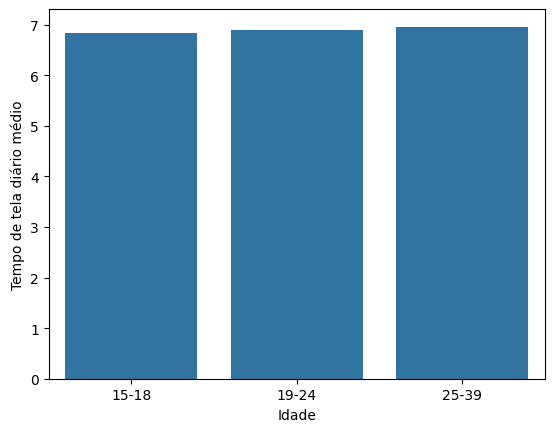

In [25]:
usomediofaixa = db.query('SELECT faixa_etaria, AVG(daily_screen_Time) FROM dflimpo GROUP BY faixa_etaria ORDER BY faixa_etaria ASC').df()
sns.barplot(data=usomediofaixa, x='faixa_etaria', y ='avg(daily_screen_Time)')
val_maxf = usomediofaixa['avg(daily_screen_Time)'].max()
val_minf = usomediofaixa['avg(daily_screen_Time)'].min()
plt.xlabel('Idade')
plt.ylabel('Tempo de tela diário médio')
plt.show()

#Conclusion: There appears to be no relation between age group and average screentime. 

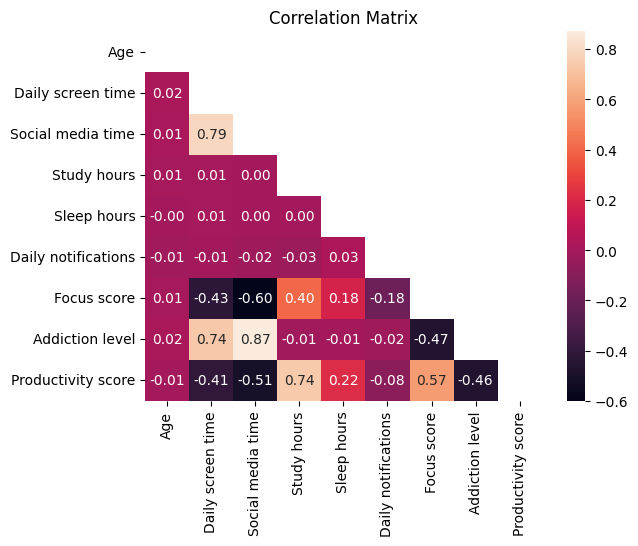

In [26]:
#Calculating the correlation matrix to confirm the previous conclusion.

mapeamento = {'High': 2, 'Medium': 1, 'Low': 0}

dfnumeric = dflimpo.copy()
dfnumeric = dfnumeric.drop(columns='faixa_etaria')
dfnumeric['addiction_level'] = df['addiction_level'].map(mapeamento)

dfnumeric.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Addiction level', 'Productivity score'] 

corr = pd.DataFrame(dfnumeric.corr())
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot = True, fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix provides us with a lot of data. Some of this data, although expected, is very important: daily screen time has a **linear negative correlation** with productivity and focus, with social media time having an **even bigger negative correlation**. This difference can be explained by the productive use of the screen (for work or study). Study hours have a **great positive correlation** with productivity and a lower but **still noticeable positive correlation** with focus. Sleep hours also have a positive correlation with both productivity and focus, but with values that are near a threshold of statistical relevance. 

The most striking correlation is between the social media time and the focus and productivity. Besides being the biggest negative correlation, one aspect is worth mentioning: the productivity score has a smaller negative correlation than focus. Users with higher addiction levels not only have more trouble being productive but also have to **exert significantly more focus** to achieve it.

Part of the data is unexpected: even though daily notifications have a **negative impact** on focus, it doesn't appear to impact productivity. Screen and social media time do not correlate with study and sleep hours, even though one would expect a negative correlation. One can deduce that this screen time is stealing time from other areas not mapped, like family/leisure time. 

In [31]:
# 1. Separate the data into the two groups we want to compare
prod_high = dflimpo[dflimpo['addiction_level'] == 'High']['productivity_score'].dropna()
prod_low = dflimpo[dflimpo['addiction_level'] == 'Low']['productivity_score'].dropna()

print(f"Size of High Addiction group: {len(prod_high)}")
print(f"Size of Low Addiction group: {len(prod_low)}\n")

# 2. Normality Test (Shapiro-Wilk)
# H0: The data follows a normal distribution
_, p_norm_high = stats.shapiro(prod_high)
_, p_norm_low = stats.shapiro(prod_low)

print("--- Assumption 1: Normality ---")
print(f"P-value (High): {p_norm_high:.4f} | P-value (Low): {p_norm_low:.4f}")

# 3. Homogeneity of Variances Test (Levene)
# H0: The variances of the groups are equal
_, p_var = stats.levene(prod_high, prod_low)

print("\n--- Assumption 2: Equal Variances ---")
print(f"Levene P-value: {p_var:.4f}\n")

# 4. Decision Tree for the Correct Test
alpha = 0.05 # Standard significance level of 5%

print("--- Hypothesis Test Result ---")

if p_norm_high > alpha and p_norm_low > alpha:
    # Both are normal
    if p_var > alpha:
        # Equal variances -> Independent Student's T-Test (Standard)
        print("Applying: Independent Student's T-Test")
        stat, p_final = stats.ttest_ind(prod_high, prod_low, equal_var=True)
    else:
        # Unequal variances -> Welch's T-Test
        print("Applying: Welch's T-Test")
        stat, p_final = stats.ttest_ind(prod_high, prod_low, equal_var=False)
else:
    # At least one is not normal -> Non-Parametric Test (Mann-Whitney U)
    print("Applying: Mann-Whitney U Test (Non-parametric)")
    stat, p_final = stats.mannwhitneyu(prod_high, prod_low, alternative='two-sided')

print(f"Test Statistic: {stat:.4f}")
print(f"Final P-Value: {p_final:.4e}")

# 5. Conclusion
if p_final < alpha:
    print("\nConclusion: We reject the Null Hypothesis (H0).")
    print("There is a statistically significant difference in productivity between the high and low addiction groups.")
else:
    print("\nConclusion: We fail to reject the Null Hypothesis (H0).")
    print("There is not enough statistical evidence to state that productivity differs between the groups.")

Size of High Addiction group: 1585
Size of Low Addiction group: 809

--- Assumption 1: Normality ---
P-value (High): 0.0000 | P-value (Low): 0.0000

--- Assumption 2: Equal Variances ---
Levene P-value: 0.0000

--- Hypothesis Test Result ---
Applying: Mann-Whitney U Test (Non-parametric)
Test Statistic: 179502.0000
Final P-Value: 4.0018e-185

Conclusion: We reject the Null Hypothesis (H0).
There is a statistically significant difference in productivity between the high and low addiction groups.


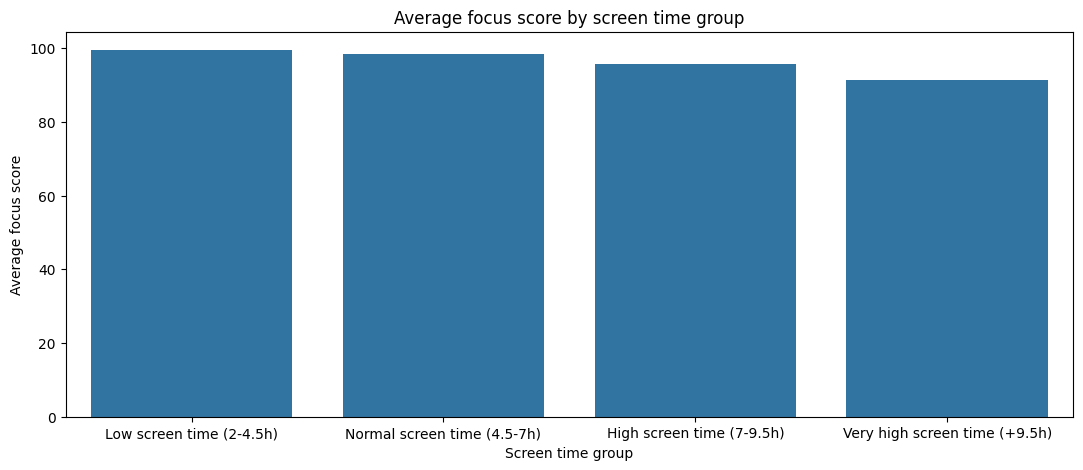

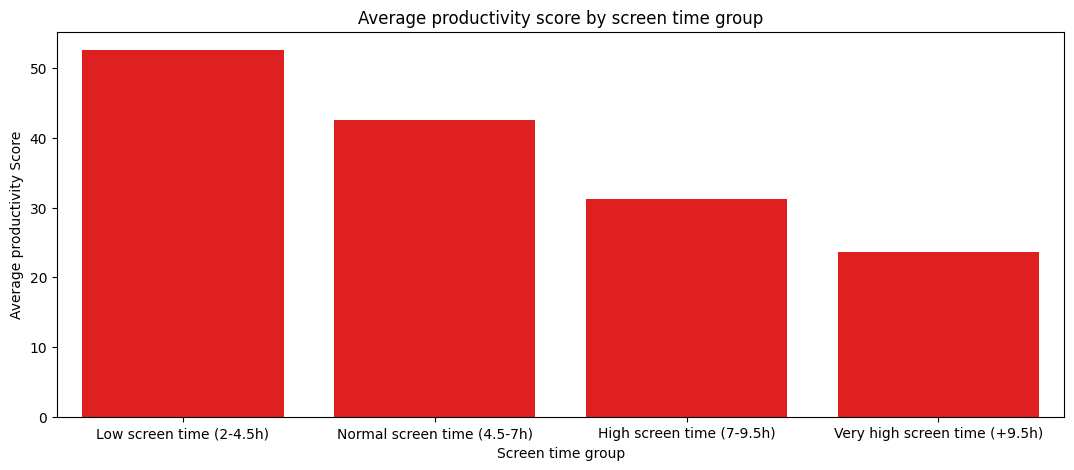

In [30]:
# Segmented analysis by screen time. Groups defined by quartiles.
screen_time_label = ['Low screen time (2-4.5h)', 'Normal screen time (4.5-7h)', 'High screen time (7-9.5h)', 'Very high screen time (+9.5h)']
dflimpo['screentime_group'] = pd.cut(dflimpo['daily_screen_time'], bins=[2, 4.5, 7, 9.5, 12], labels=screen_time_label, right=False)

focus_prod = db.query('SELECT screentime_group, AVG(focus_score), AVG(productivity_score) FROM dflimpo GROUP BY screentime_group ORDER BY screentime_group').df()

plt.figure(figsize = (13, 5))
sns.barplot(data=focus_prod, x='screentime_group', y ='avg(focus_score)')
plt.title('Average focus score by screen time group')
plt.xlabel('Screen time group')
plt.ylabel('Average focus score')
plt.show()

plt.figure(figsize = (13, 5))
sns.barplot(data=focus_prod, x='screentime_group', y ='avg(productivity_score)', color='red')
plt.title('Average productivity score by screen time group')
plt.xlabel('Screen time group')
plt.ylabel('Average productivity Score')
plt.show()



Screen time has a small influence on focus. Users with low screen time have a near-perfect average focus score of **99.51**, while very high screen time users have approximately a 8% decrease, with **91.25 average focus score**.

The influence on productivity, however, is astounding. Low screen time users have a **average productivity score of 52.61**. Normal screen time users have a 19% decrease **(42.60 productivity score)**, high screen time users have a 40% decrease, with a score of **31.20** and very high screen time users have a total decrease of 55% in productivity score, which amounts to a value of only **23.60**.